# PyTorch Convolutional Neural Network (CNN) With CIFAR-10 Color Image Dataset

In this example, we demonstrate how to train a CNN model (aka ConvNet)  to classify images from the CIFAR-10 dataset. With the nature of CNN can handle spatial data of images and video, the RGB-color images  of CIFAR-10 can be directly use as input to the model.

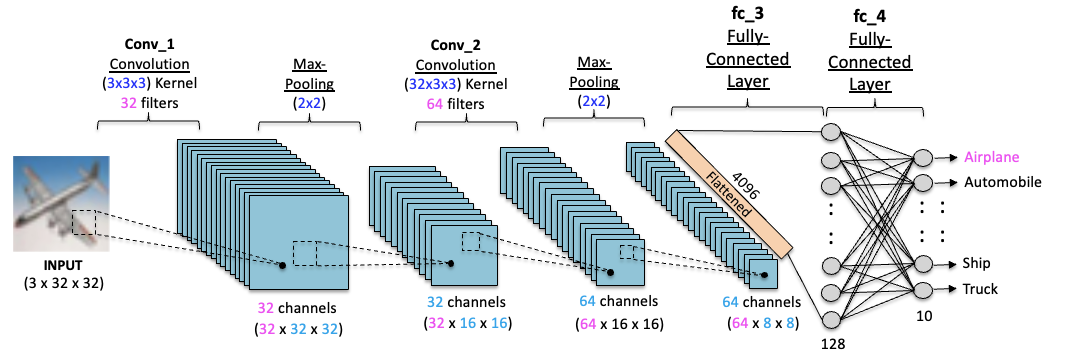

The CIFAR-10 dataset is a widely used collection of images that is commonly used to train machine learning and computer vision algorithms

It consists of 60,000 32x32 color images in 10 different classes
Each class contains 6,000 images, with 5,000 images for training and 1,000 images for testing
The 10 different classes in the CIFAR-10 dataset represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks
The CIFAR-10 dataset can be split into training set, validation set, and test set in various ways. In this example, the way is to use 45,000 images for training, 5,000 images for validation, and 10,000 images for testing.

References:

1. https://github.com/nestorojeda/CIFAR-10-CNN  
2. Jordan, K. (2024). *94% on CIFAR-10 in 3.29 Seconds on a Single GPU*. https://arxiv.org/html/2404.00498v2


## Assignment 2: Summary Report

This report summarizes the model design, training setup, and results for **CNN4 (RegNetY-400MF)** on **CIFAR-10**.

---

### 1. Model Architecture Design

| Item | Description |
|------|-------------|
| **Model name** | CNN4 (RegNetY-400MF backbone, **no pretrained** — train from scratch) |
| **Dataset** | CIFAR-10: 50,000 training, 5,000 validation, 5,000 test |
| **Input** | Resize to 224×224; normalize with ImageNet mean/std (0.485, 0.456, 0.406) / (0.229, 0.224, 0.225) |
| **Backbone** | `torchvision.models.regnet_y_400mf(weights=None)` |
| **Head** | Final linear layer replaced with `nn.Linear(..., 10)` for 10 classes |
| **Design** | RegNet blocks (depthwise conv, inverted bottleneck, LayerNorm-style normalization); **100 epochs** training from scratch |

---

### 2. Training Process

| Item | Setting |
|------|---------|
| **Augmentation** | `AutoAugment(AutoAugmentPolicy.CIFAR10)`; **alternating horizontal flip** (per-sample flip by `(hash(index) + epoch) % 2`) |
| **Optimizer** | AdamW `lr=1e-4`, `weight_decay=5e-4` |
| **Loss** | `CrossEntropyLoss(label_smoothing=0.01)` (label smoothing to reduce overconfidence) |
| **Scheduler** | `CosineAnnealingLR(T_max=EPOCHS, eta_min=5e-7)` |
| **Batch size** | 96 |
| **Other** | Mixed precision (`torch.cuda.amp`) on CUDA; `torch.compile` (reduce-overhead) for lower Python overhead; cuDNN benchmark, TF32, channels-last memory format for speed |

---

### 3. Experimental Results

**Before training:** Leave placeholders below as is; `EPOCHS=100`, no pretrained weights. **After training:** Fill in the values from your run.

Record:

* **Best validation accuracy:** _____% at epoch _____
* **Training accuracy (last epoch):** _____%
* **Validation loss (best epoch):** _____
* **Test accuracy (5,000 test images):** _____%
* **Test loss:** _____
* **Total training time:** _____ s

Loss/accuracy curves are plotted below; best model is loaded from `Models/regnet_model_{best_epoch}.pth` for test evaluation.

---

### 4. Evaluation

The notebook reports:

* **Test loss** and **test accuracy** on the 5,000-image test split
* **Confusion matrix** (rows = true class, columns = predicted)
* **Per-class metrics:** precision, recall, F1, support via `classification_report(y_true, y_pred)`

Wrongly classified examples are visualized by class.

---

### 5. Conclusions

* RegNetY-400MF trained from scratch (no pretrained weights) for 100 epochs with full training optimizations (augmentation, scheduler, etc.).
* Alternating flip and AutoAugment provide effective augmentation; best checkpoint is selected by validation accuracy.
* Test metrics are reported on the chosen model; update Section 3 with your run’s numbers.

---

### 6. References & related work

**Jordan (2024)** — [94% on CIFAR-10 in 3.29 Seconds on a Single GPU](https://arxiv.org/html/2404.00498v2) (arXiv:2404.00498v2). Fast CIFAR-10 training with alternating flip and other tricks. Cited in the References list at the top; same dataset, different architecture and augmentation here.


In [1]:
# Install the torchinfo package for showing the network architecture information
!pip install torchinfo -qqq


In [2]:
# Import the necessary libraries for working with CIFAR-10 dataset and PyTorch.
import torch
import torchvision
from torchvision import datasets,transforms
import torch.nn as nn
import torch.nn.functional as F
from torch import nn,optim,no_grad
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchinfo import summary

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import sys
import time

import torchvision.models as models
from torch import amp, autocast
import warnings
warnings.filterwarnings("ignore", message="Not enough SMs to use max_autotune_gemm")


In [3]:
# To configure the usage of a GPU (cuda) or MPS (Apple) if either of them is available
has_mps = torch.backends.mps.is_built()
device = "cuda" if torch.cuda.is_available() else "mps" if has_mps else "cpu"

# Strict CUDA OOM mode: cap VRAM and fail fast instead of spilling to shared/system memory
STRICT_CUDA_OOM = True
CUDA_MEMORY_FRACTION = 0.999
if device == "cuda" and STRICT_CUDA_OOM:
    torch.cuda.set_per_process_memory_fraction(CUDA_MEMORY_FRACTION)
    print(f"Strict CUDA OOM mode ON (memory fraction cap: {CUDA_MEMORY_FRACTION:.2f})")

print(f"Python version: {sys.version_info.major, sys.version_info.minor, sys.version_info.micro}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


Strict CUDA OOM mode ON (memory fraction cap: 1.00)
Python version: (3, 12, 12)
PyTorch version: 2.10.0+cu130
Device: cuda


In [4]:
# Set seed for reproducibility
seed = 1339
torch.manual_seed(seed)


# Download CIFAR10 Dataset

This piece of code helps in downloading and managing the training and test data for a model. The training dataset used is called CIFAR-10 and it has 50,000 training samples. The test dataset is divided into two parts: a validation set and a test set, each with 5,000 samples. The data loaders help in providing batches of data from these datasets for the model to train on. The training data consists of batches of images, where each image is a 32 x 32 pixel color image. The corresponding labels indicate the correct class for each image, such as airplanes, cars, birds, cats, etc.


In [5]:
# Define data transformations for the training and test sets
train_transform = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),  # Apply strong data augmentation
    transforms.Resize(224),  # Resize images to higher resolution
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # Normalize the image data
])

test_transform = transforms.Compose([
    transforms.Resize(224),  # Resize images to higher resolution
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)), # Use ImageNet normalization
])

# Create the CIFAR10 dataset for the training set with 50,000 images
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

# Create the CIFAR10 dataset for the test set with 10,000 images
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Split the original test set into a validation set with 5,000 samples and a test set with 5,000 samples
val_set, test_set = torch.utils.data.random_split(test_dataset, [5000, 5000])

# pin_memory speeds up host->GPU copies (CUDA only)
pin_memory = (device == "cuda")

# Define the data loaders for the training, validation, and test sets
train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True, num_workers=4, pin_memory=pin_memory, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=256, shuffle=False, num_workers=4, pin_memory=pin_memory, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=4, pin_memory=pin_memory, persistent_workers=True)

# Define the classes for the CIFAR-10 dataset
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Visualize image for each class

The first step in a classification task is to take a look at the data, make sure it is loaded in correctly, then make any initial observations about patterns in that data.


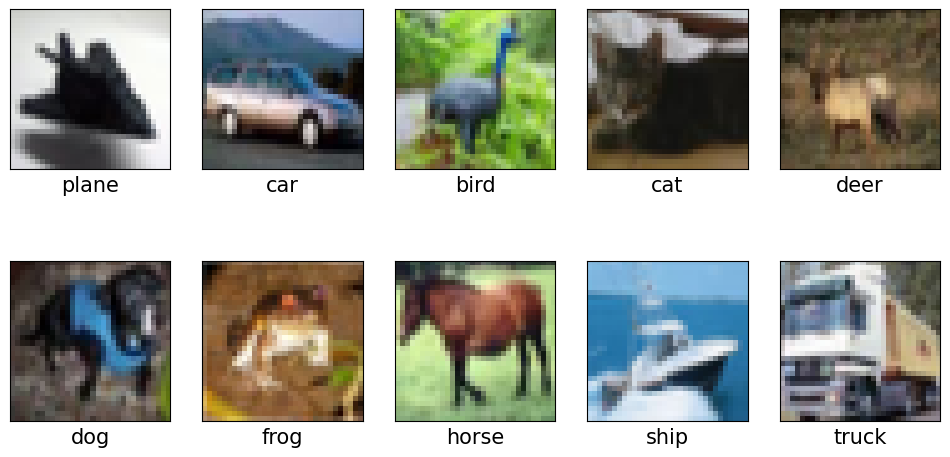

In [6]:
# Visualize training image for each class
sample_images = [train_set.data[np.asarray(train_set.targets) == label][0] for label in range(10)]

# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel(classes[i], fontsize=15)
    axis.imshow(sample_images[i])
    i += 1


## Define the Model (RegNetY-400MF backbone)

This notebook uses a **RegNetY-400MF** backbone **without pretrained weights** (train from scratch) and replaces its classifier head for CIFAR-10 (10 classes). Training runs for **100 epochs**.

RegNet is a modern convolutional network architecture that incorporates depthwise convolutions, inverted bottlenecks, and LayerNorm-style normalization, offering strong performance and transfer learning capabilities.


In [7]:
# No pretrained weights: train from scratch
model = models.regnet_y_400mf(weights=None)

# Replace the classification head for CIFAR-10 (10 output classes)
model.fc = nn.Linear(model.fc.in_features, 10)


In [8]:
summary(model=model, input_size=(1, 3, 224, 224), col_width=15,
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'], verbose=0)


Layer (type (var_name))                                      Input Shape     Output Shape    Param #         Trainable
RegNet (RegNet)                                              [1, 3, 224, 224] [1, 10]         --              True
├─SimpleStemIN (stem)                                        [1, 3, 224, 224] [1, 32, 112, 112] --              True
│    └─Conv2d (0)                                            [1, 3, 224, 224] [1, 32, 112, 112] 864             True
│    └─BatchNorm2d (1)                                       [1, 32, 112, 112] [1, 32, 112, 112] 64              True
│    └─ReLU (2)                                              [1, 32, 112, 112] [1, 32, 112, 112] --              --
├─Sequential (trunk_output)                                  [1, 32, 112, 112] [1, 440, 7, 7]  --              True
│    └─AnyStage (block1)                                     [1, 32, 112, 112] [1, 48, 56, 56] --              True
│    │    └─ResBottleneckBlock (block1-0)                    [1, 3

## Training the Network

The steps for training/learning from a batch of data are described in the comments below:

Clear the gradients of all optimized variables
Forward pass: compute predicted outputs by passing inputs to the model
Calculate the loss
Backward pass: compute gradient of the loss with respect to model parameters
Perform a single optimization step (parameter update)
Update average training loss
The following loop trains for 50 epochs; take a look at how the values for the training loss decrease over time. We want it to decrease while also avoiding overfitting the training data.


In [9]:
# Create a Models folder to store the checkpoints
!mkdir Models


mkdir: cannot create directory ‘Models’: File exists


## Specify Loss Function and Optimizer
It's recommended that you use cross-entropy loss for classification. If you look at the documentation (linked above), you can see that PyTorch's cross entropy function applies a softmax funtion to the output layer and then calculates the log loss.


In [10]:
EPOCHS = 100

criterion = nn.CrossEntropyLoss(label_smoothing=0.01)  # Cross-Entropy Loss for multi-class classification

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4,)

# Specify Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=5e-7)


In [11]:
best_val_acc = 0.0
best_epoch = 0

# Mixed precision training setup (only enabled on CUDA)
scaler = amp.GradScaler(enabled=(device == "cuda"))

# Training history tracking
loss_hist, acc_hist = [], []            # training loss / acc per epoch
loss_hist_val, acc_hist_val = [], []    # validation loss / acc per epoch

# Enable faster CUDA kernels for fixed-shape CNN workloads.
if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
    model = model.to(device=device, memory_format=torch.channels_last)
    model = torch.compile(model, mode="reduce-overhead")
else:
    model = model.to(device)

print("Training was started.\n")
time_total_start = time.time()

# Helper: format learning rate in full decimal form (no scientific notation)
def format_lr(lr: float) -> str:
    s = f"{lr:.10f}"
    s = s.rstrip("0").rstrip(".")
    if s == "0":
        s = "0.0"
    return s

for epoch in range(1, EPOCHS + 1):
    time_ckpt = time.time()
    print("EPOCH:", epoch, end=" ")
    # Accumulate on device to avoid .item() every step (GPU–CPU sync bottleneck)
    running_loss = torch.tensor(0.0, device=device)
    correct = torch.tensor(0, device=device, dtype=torch.long)

    # Training loop
    model.train()
    for batch_idx, data in enumerate(train_loader):
        batch, labels = data
        if device == "cuda":
            batch = batch.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            batch = batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # ===== Updated Alternating Flip (vectorized, branch-free) =====
        # Build deterministic pseudo-indices per batch (single-notebook safe on Windows workers).
        idx = torch.arange(labels.size(0), device=device, dtype=torch.long) + batch_idx * train_loader.batch_size
        hash_idx = (idx * 2654435761) % (2 ** 32)  # 32-bit hash

        # Add .view(-1, 1, 1, 1) so the mask broadcasts to image dimensions (N, C, H, W)
        flip_mask = ((hash_idx + epoch) % 2 == 1).view(-1, 1, 1, 1)

        # Flip the entire batch, then use torch.where to select flipped vs non-flipped images
        batch = torch.where(flip_mask, torch.flip(batch, dims=[3]), batch)
        # ===========================================================

        optimizer.zero_grad()  # Clear the gradients

        # Autocast is only meaningful on CUDA; fallback to CPU otherwise.
        autocast_device = "cuda" if device == "cuda" else "cpu"
        with autocast(device_type=autocast_device):
            outputs = model(batch)
            loss = criterion(outputs, labels)

        if device == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        # Compute training statistics (stay on device; no .item() per step)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        running_loss += loss.detach().float()

    avg_loss = (running_loss / len(train_loader)).item()
    avg_acc = correct.item() / len(train_set)
    loss_hist.append(avg_loss)
    acc_hist.append(avg_acc)

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        loss_val = torch.tensor(0.0, device=device)
        correct_val = torch.tensor(0, device=device, dtype=torch.long)

        for data in val_loader:
            batch, labels = data
            if device == "cuda":
                batch = batch.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                batch = batch.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(device_type=autocast_device):
                outputs = model(batch)
                loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum()
            loss_val += loss.float()

        avg_loss_val = (loss_val / len(val_loader)).item()
        avg_acc_val = correct_val.item() / len(val_set)
        loss_hist_val.append(avg_loss_val)
        acc_hist_val.append(avg_acc_val)

    model.train()       # Set the model back to training mode
    scheduler.step()    # Update the learning rate scheduler

    current_lr = optimizer.param_groups[0]["lr"]

    # Track best validation accuracy
    is_best = avg_acc_val > best_val_acc
    if is_best:
        best_val_acc = avg_acc_val
        best_epoch = epoch

    # Save the model at the end of each epoch
    model.eval()
    torch.save(model.state_dict(), f"Models/regnet_model_{epoch}.pth")
    model.train()

    # Print training statistics
    print(f"LR: {format_lr(current_lr)}", end=" ")
    print("Train Loss: {:.4f}".format(avg_loss), end=" ")
    print("Val Loss: {:.4f}".format(avg_loss_val), end=" ")
    print("Train Acc: {:.2f}%".format(avg_acc * 100), end=" ")
    print("Val Acc: {:.2f}%".format(avg_acc_val * 100), end=" ")
    print("Time: {:.2f}s".format(time.time() - time_ckpt), end="")
    if is_best:
        print(" Best!", end="")
    print()  # new line

time_total = time.time() - time_total_start
print(f"\n✓ Training completed! Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")
print("Per-epoch checkpoints saved in Models/regnet_model_{epoch}.pth")
print(f"Total training time: {time_total:.2f}s ({time_total/60:.2f} min)")


Training was started.

EPOCH: 1 

W0315 17:42:16.385000 1628 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


LR: 0.0000999755 Train Loss: 2.1485 Val Loss: 1.8225 Train Acc: 20.51% Val Acc: 32.82% Time: 190.38s Best!
EPOCH: 2 LR: 0.0000999018 Train Loss: 1.8962 Val Loss: 1.6185 Train Acc: 29.96% Val Acc: 41.28% Time: 60.02s Best!
EPOCH: 3 LR: 0.0000997792 Train Loss: 1.7655 Val Loss: 1.5064 Train Acc: 35.62% Val Acc: 44.96% Time: 62.82s Best!
EPOCH: 4 LR: 0.0000996077 Train Loss: 1.6700 Val Loss: 1.4075 Train Acc: 39.44% Val Acc: 49.16% Time: 51.86s Best!
EPOCH: 5 LR: 0.0000993875 Train Loss: 1.5923 Val Loss: 1.3302 Train Acc: 42.85% Val Acc: 52.86% Time: 57.45s Best!
EPOCH: 6 LR: 0.0000991188 Train Loss: 1.5299 Val Loss: 1.2692 Train Acc: 45.18% Val Acc: 55.50% Time: 57.96s Best!
EPOCH: 7 LR: 0.0000988019 Train Loss: 1.4703 Val Loss: 1.2127 Train Acc: 47.86% Val Acc: 57.00% Time: 60.47s Best!
EPOCH: 8 LR: 0.000098437 Train Loss: 1.4085 Val Loss: 1.1707 Train Acc: 50.10% Val Acc: 59.96% Time: 54.15s Best!
EPOCH: 9 LR: 0.0000980246 Train Loss: 1.3519 Val Loss: 1.1127 Train Acc: 52.21% Val Acc: 

## Plotting Training Statistics

Loss is a function of the difference of the network output and the target values. We are minimizing the loss function during training so it should decrease over time. Accuracy is the classification accuracy for the test data.


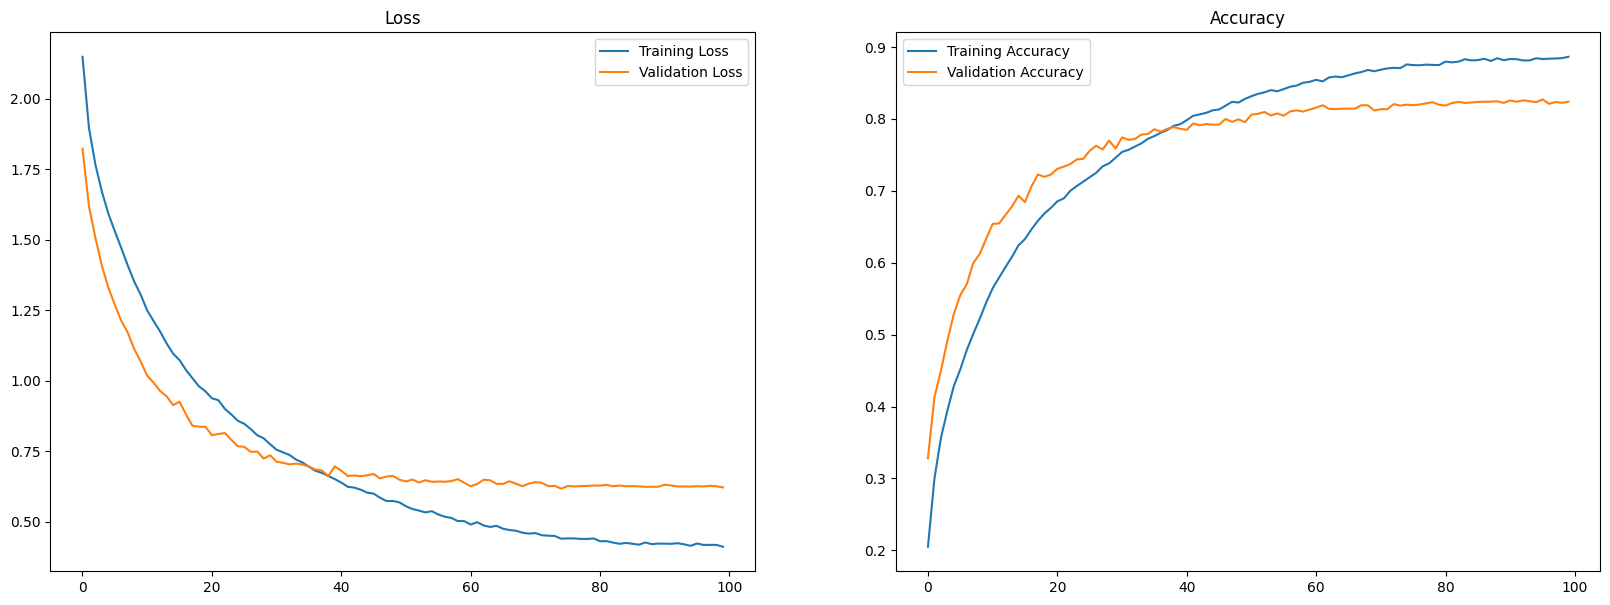

In [12]:
plots=[(loss_hist,loss_hist_val),(acc_hist,acc_hist_val)]
plt_labels=[("Training Loss","Validation Loss"),("Training Accuracy","Validation Accuracy")]
plt_titles=["Loss","Accuracy"]
plt.figure(figsize=(20,7))
for i in range(0,2):
    ax=plt.subplot(1,2,i+1)
    ax.plot(plots[i][0],label=plt_labels[i][0])
    ax.plot(plots[i][1],label=plt_labels[i][1])
    ax.set_title(plt_titles[i])
    ax.legend()


## Save the trained model


In [13]:
# from google.colab import files
# torch.save(model.state_dict(), 'checkpoint.pth')
# # download checkpoint file
# files.download('checkpoint.pth')
# model.load_state_dict(torch.load('checkpoint.pth'))


In [14]:
# Selecting the best model
best_acc = max(acc_hist_val)
best_epoch = acc_hist_val.index(best_acc)+1

print("Best accuracy on validation set: {:.2f}%".format(best_acc*100))
print("Best epoch: {}".format(best_epoch))

state_dict = torch.load(
    f"Models/regnet_model_{best_epoch}.pth",
    map_location=device
)

model.load_state_dict(state_dict)
if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)
model.eval()


Best accuracy on validation set: 82.70%
Best epoch: 96


OptimizedModule(
  (_orig_mod): RegNet(
    (stem): SimpleStemIN(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (trunk_output): Sequential(
      (block1): AnyStage(
        (block1-0): ResBottleneckBlock(
          (proj): Conv2dNormActivation(
            (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(2, 2), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (f): BottleneckTransform(
            (a): Conv2dNormActivation(
              (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
            )
            (b): Conv2dNormActivation(
              (0): Conv2d(48, 48, kernel_size=(

# Test the Trained Network
Finally, we test our best model on previously unseen test data and evaluate it's performance. Testing on unseen data is a good way to check that our model generalizes well. It may also be useful to be granular in this analysis and take a look at how this model performs on each class as well as looking at its overall loss and accuracy.


In [15]:
pred_vec = []
label_vec = []
correct = 0

if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)
model.eval()

test_loss_sum = 0.0   # accumulate loss * batch_size over all batches
test_samples = 0      # total number of samples

with torch.no_grad():
    for data in test_loader:
        batch, labels = data
        if device == "cuda":
            batch = batch.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            batch = batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(batch)
        loss = criterion(outputs, labels)

        # accumulate loss for weighted average
        batch_size = labels.size(0)
        test_loss_sum += loss.item() * batch_size
        test_samples += batch_size

        # accumulate correct predictions and store predictions/labels
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        pred_vec.extend(predicted.cpu().numpy())
        label_vec.extend(labels.cpu().numpy())

# compute average loss over the whole test set
test_loss = test_loss_sum / test_samples

pred_vec = np.array(pred_vec)
label_vec = np.array(label_vec)


# Display the Test Set Accuracy


In [16]:
print("Test Loss: {:.2f}".format(test_loss))
print('Test set Accuracy on the 5,000 test images: %.2f %%' % (100 * correct / len(test_set)))


Test Loss: 0.63
Test set Accuracy on the 5,000 test images: 82.32 %


# Display the Confusion Matrix


In [17]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_mat = confusion_matrix(label_vec, pred_vec)
# Convert confusion matrix to pandas DataFrame
labels = np.unique(label_vec)
confusion_df = pd.DataFrame(confusion_mat, index=classes, columns=classes)
print("Confusion Matrix")
confusion_df


Confusion Matrix


,plane,car,bird,cat,deer,dog,frog,horse,ship,truck
plane,418,4,20,5,7,4,0,2,22,9
car,6,444,0,5,1,2,2,3,9,25
bird,20,2,379,20,31,15,25,6,5,2
cat,6,0,31,344,13,67,23,17,10,5
deer,3,0,16,16,398,13,13,23,4,1
dog,2,1,16,66,24,372,8,14,4,2
frog,4,0,10,24,10,7,421,3,2,0
horse,5,0,10,14,13,12,2,438,0,1
ship,16,9,8,3,4,3,4,0,469,9
truck,9,20,3,11,1,1,3,5,8,433


# Compute the Accuracy, F1-Score, Precision, Recall, Support


In [18]:
# Create a report to show the f1-score, precision, recall
from sklearn.metrics import classification_report

report = pd.DataFrame.from_dict(classification_report(label_vec, pred_vec, output_dict=True)).T
report['Label']=[classes[int(x)] if x.isdigit() else " " for x in report.index]
report=report[['Label','f1-score','precision','recall','support']]
report


,Label,f1-score,precision,recall,support
0,plane,0.853061,0.854806,0.851324,491.0000
1,car,0.908905,0.925000,0.893360,497.0000
2,bird,0.759519,0.768763,0.750495,505.0000
3,cat,0.671875,0.677165,0.666667,516.0000
4,deer,0.804853,0.792829,0.817248,487.0000
5,dog,0.740299,0.750000,0.730845,509.0000
6,frog,0.857434,0.840319,0.875260,481.0000
7,horse,0.870775,0.857143,0.884848,495.0000
8,ship,0.886578,0.879925,0.893333,525.0000
9,truck,0.882773,0.889117,0.876518,494.0000


In the context of classification, 'support' refers to the number of instances or samples in a dataset that belong to a specific class. It represents the frequency or count of occurrences of each class in the dataset.

Support values help assess the reliability and generalizability of classification models, as they indicate the amount of data available for each class and the potential challenges associated with imbalanced datasets.


# Visualize Sample Test Results
This cell displays test images and their labels in this format: predicted (ground-truth). The text will be green for accurately classified examples and red for incorrect predictions.


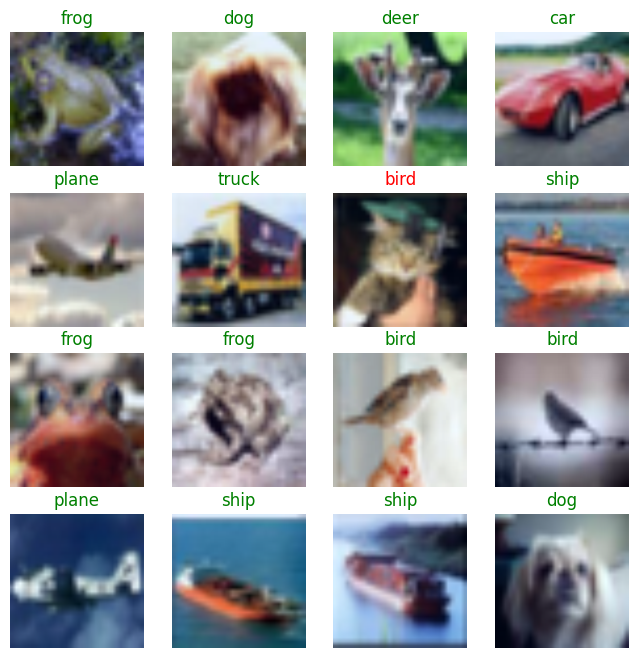

In [19]:
# obtain one batch of test images
images, labels = next(iter(test_loader))
# Keep model on device (torch.compile does not support .cpu()). Run inference on device.
images = images.to(device)
with torch.no_grad():
    output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
images, preds = images.cpu(), preds.cpu()  # move to CPU for plotting

# Create a 4x4 grid for displaying the images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Iterate over the images and display them in the grid
for idx, ax in enumerate(axes.flat):
  # Normalize the image tensor to [0, 1] range
  image = images[idx].permute(1, 2, 0)
  image = (image - image.min()) / (image.max() - image.min())
  ax.imshow(image)  # Display the image
  ax.axis('off')  # Hide the axes
  ax.set_title("{}".format(classes[preds[idx]]),
                 color=("green" if preds[idx]==labels[idx] else "red"))  # Add title to the image
plt.show()


#Display 50 Predicted Images
We iterate through 50 images and plot them with their corresponding label. We will color the label in blue if our model guessed correct and in red if it failed to predict that class.


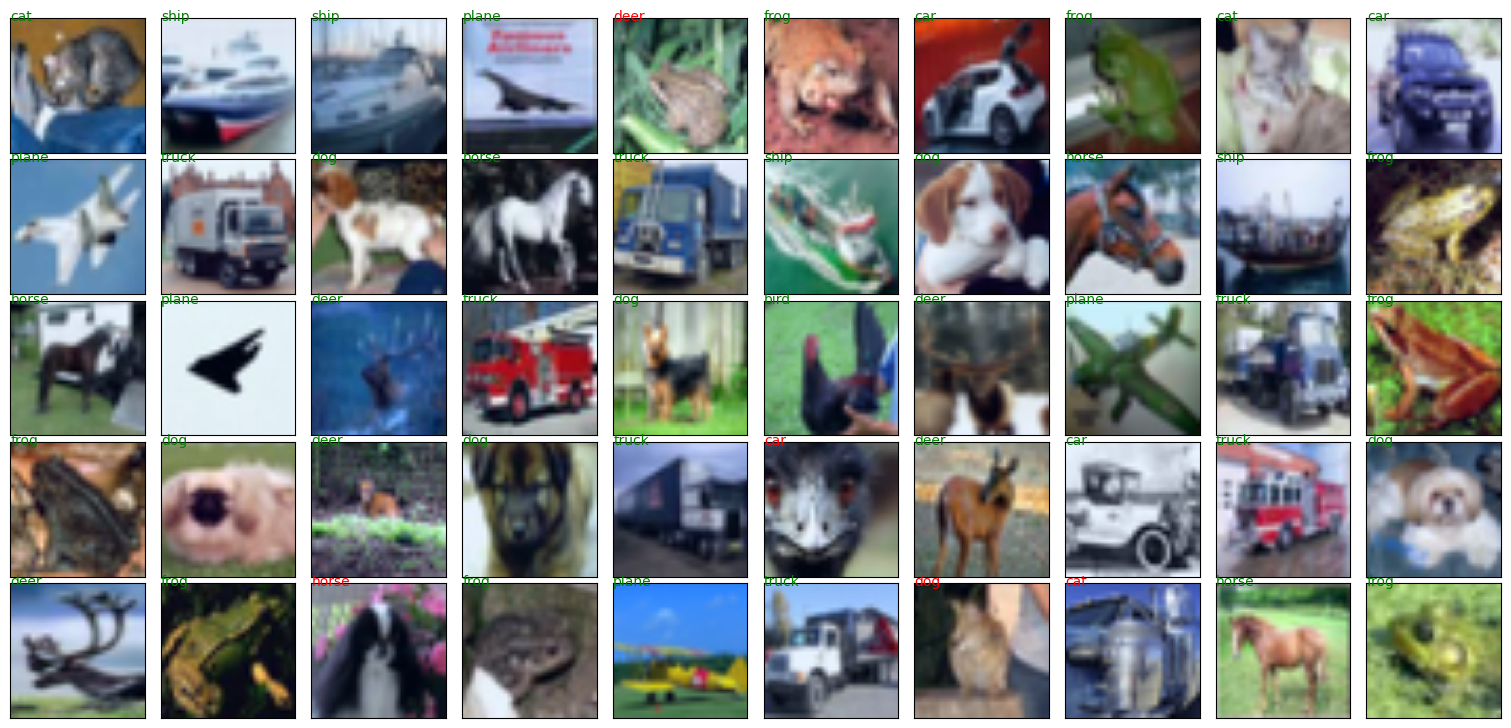

In [20]:
# Define the loader for all test data
test_set_all = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)
test_loader_all = torch.utils.data.DataLoader(test_set_all, batch_size=192, shuffle=False, num_workers=4)


# obtain one batch of test images
dataiter = iter(test_loader_all)
images, labels = next(iter(test_loader_all))
model.to(device)
images = images.to(device)
labels = labels.to(device)

# get sample outputs
with torch.no_grad():
    output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
images, preds, labels = images.cpu(), preds.cpu(), labels.cpu()  # for matplotlib

fig = plt.figure(figsize=(15, 7))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for idx in range(50):
    # Normalize the image tensor to [0, 1] range
    image = images[idx].permute(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min())
    ax = fig.add_subplot(5, 10, idx + 1, xticks=[], yticks=[])
    ax.imshow(image, interpolation='nearest')

    if preds[idx]==labels[idx]:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='green')
    else:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='red')

plt.show()


## Visualize wrongly classified image for each class


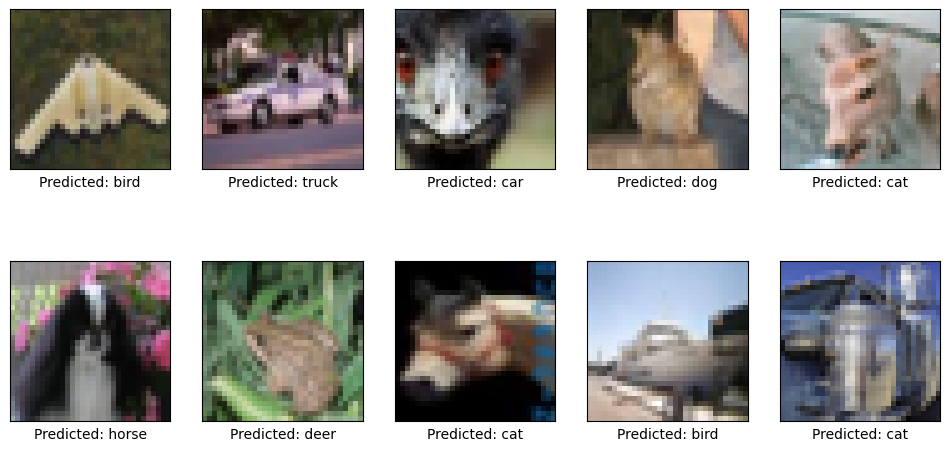

In [21]:
# Visualize wrongly classified image for each class
pred_vec_all = []
correct = 0
test_loss = 0.0

if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)

with torch.no_grad():
    for data in test_loader_all:
        batch, labels = data
        if device == "cuda":
            batch = batch.to(device, memory_format=torch.channels_last)
        else:
            batch = batch.to(device)
        labels = labels.to(device)
        outputs = model(batch)
        test_loss=criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        pred_vec_all.append(predicted)
    pred_vec_all = torch.cat(pred_vec_all)

pred_vec_all = pred_vec_all.cpu().numpy()
ground_truths = np.asarray(test_set_all.targets)
incorrect_mask = pred_vec_all != ground_truths
# One (wrong if any, else any) sample per class to avoid IndexError when a class has no errors
incorrect_images = []
pred_results_all = []
for label in range(10):
    wrong_mask = (ground_truths == label) & incorrect_mask
    if wrong_mask.any():
        idx = np.where(wrong_mask)[0][0]
        incorrect_images.append(test_set_all.data[idx])
        pred_results_all.append(pred_vec_all[idx])
    else:
        idx = np.where(ground_truths == label)[0][0]
        incorrect_images.append(test_set_all.data[idx])
        pred_results_all.append(pred_vec_all[idx])

# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel("Predicted: %s" % classes[pred_results_all[i]], fontsize=10)
    axis.imshow(incorrect_images[i], cmap='gray')
    i += 1
